# Elastic Vector-Reflectivity — Forward Validation (Soares & Sacchi 2025)

Reproduces the **forward-modelling validation** of Soares & Sacchi (2025, SEG,
doi 10.1190/image2025-4316471.1) — the *first-order momentum–stress
vector-reflectivity* elastic wave equation. **No inversion here**; this is the
paper's Sec 5 / Fig 2–3 consistency check.

**The reparameterisation.** The state variable is particle **momentum**
`p_i = ρ·v_i` instead of velocity, so the momentum equation collapses to the
plain divergence form `∂_t p_i = ∂_j σ_ij` with **no density left**. All
ρ-dependence moves into the constitutive law through the impedance **vector
reflectivity** `R_{α,i} = ½ Z_α⁻¹ ∂_i Z_α` with `Z_α = ρ V_α`. The model is
therefore `(V_P, V_S, R_{P,x}, R_{P,z}, R_{S,x}, R_{S,z})` — **no ρ field**.

**The validation.** Run the *same* physical 3-layer model through two solvers
and confirm the shot gathers match:

1. `Elastic` — standard variable-density Virieux, model `[vp, vs, rho]`.
2. `ElasticVectorReflectivity` — model `[vp, vs, Rp_x, Rp_z, Rs_x, Rs_z]`, with
   `R` derived from `(vp, vs, rho)` via `compute_vector_reflectivity`.

Both use an **explosive** `['sxx','szz']` source and record **stress**
`['sxx','szz']`; we compare the pressure-equivalent `½(σxx+σzz)`. Stress is
identical physics in both formulations, so **no ρ conversion** is needed. Both
forward runs use the CUDA backend (`impl='c'`).

Paper's claim: the gathers agree to ~1%, with the residue concentrated at the
layer interfaces (staggered-grid interpolation of the variable-coefficient
`V·∂V·p` / `R·p` terms), while the **direct wave is identical**.

## 1. Parameters

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Elastic, ElasticVectorReflectivity, compute_vector_reflectivity
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# S&S 2025 Fig 1 model + acquisition
NZ, NX = 400, 600
DH     = 5.0       # m   -> 2000 m x 3000 m domain
DT     = 5e-4      # s
NT     = 3000      # 1.5 s record
SO     = 8         # spatial order -> passed to the EQUATION constructor (not PropTorch)
ABCN   = 50        # CPML width
FREQ   = 15.0      # Ricker peak frequency (Hz)
DELAY  = 0.1       # s
SRC_IX, SRC_IZ = 300, 4    # explosive source at (x=1500 m, z=20 m)
REC_IZ = 4                 # receiver line at z=20 m, full x-range
print('device:', device)

device: cuda


## 2. Model (Soares & Sacchi 2025, Fig 1) and its vector reflectivity

The paper's model is two **wavy** interfaces — `vp` 1500/2500/3500 m/s,
`vs` 600/900/1200 m/s, `rho` 1000/1500/2000 kg/m³ — plus a **circular
density-only anomaly** in the middle layer: `vp` and `vs` carry **no** anomaly,
only `rho` does. That is the showcase for the vector-reflectivity idea — a pure
impedance/density contrast that a velocity-only parameterisation cannot see but
`R = ½ ∂ᵢ ln Z` captures.

`compute_vector_reflectivity` is the bridge from `(vp, vs, rho)` to the EVR
parameters. The **vertical** reflectivity (`Rp_z, Rs_z`) traces the wavy
interfaces and the circle; the **horizontal** reflectivity (`Rp_x, Rs_x`) is
non-zero only where structure varies laterally — the interface slopes and the
circle's flanks.

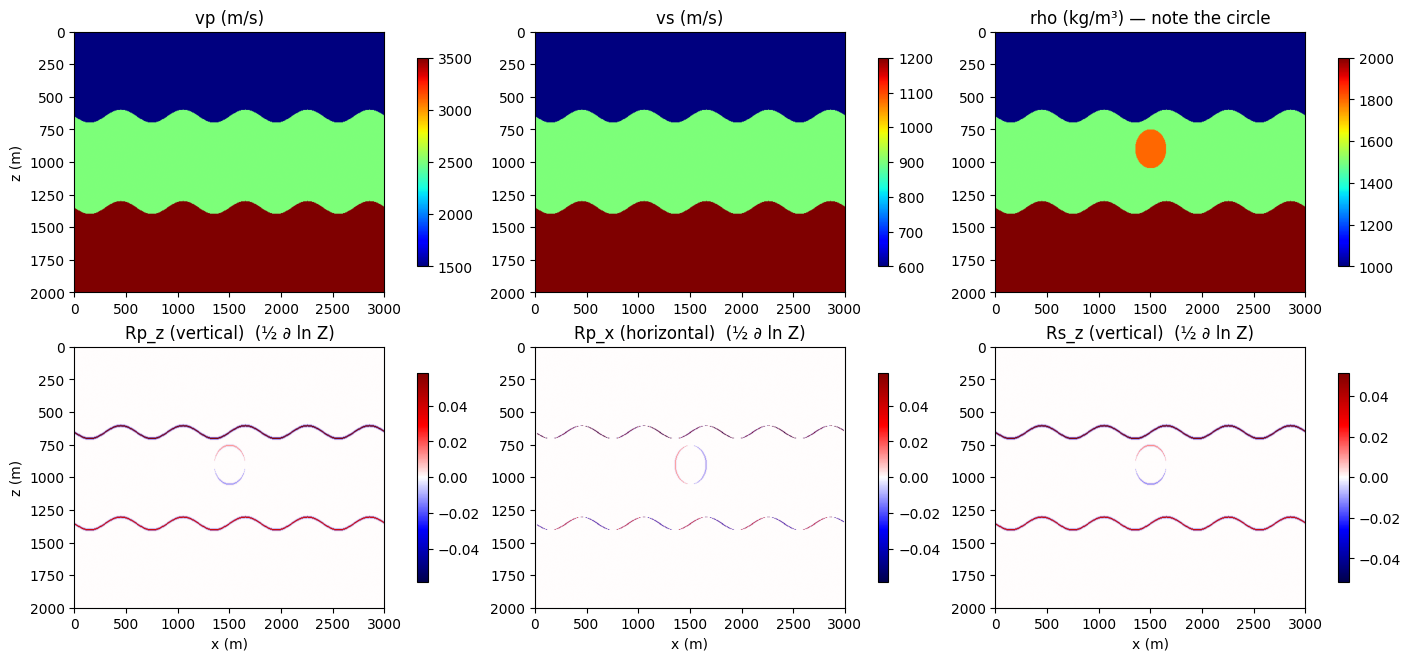

Rs_x mirrors Rp_x in structure (both ~0 except at slopes / circle flanks).


In [2]:
# --- S&S 2025 Fig 1: two WAVY interfaces + a circular density-only anomaly ---
zz, xx = np.mgrid[0:NZ, 0:NX].astype(np.float64)
amp, wl = 10.0, 120.0                               # ~50 m undulation, ~600 m wavelength
iface1 = 130.0 + amp * np.sin(2 * np.pi * xx / wl)  # ~650 m
iface2 = 270.0 + amp * np.sin(2 * np.pi * xx / wl)  # ~1350 m

def three_layer(top, mid, bot):
    m = np.full((NZ, NX), bot, np.float32)
    m[zz < iface2] = mid
    m[zz < iface1] = top
    return m

vp_np  = three_layer(1500., 2500., 3500.)
vs_np  = three_layer( 600.,  900., 1200.)
rho_np = three_layer(1000., 1500., 2000.)
# density-only circular anomaly (center x=1500 m, z=900 m, radius 150 m)
circ = (zz - 180.) ** 2 + (xx - 300.) ** 2 < 30. ** 2
rho_np[circ] = 1800.

vp  = torch.tensor(vp_np,  device=device)
vs  = torch.tensor(vs_np,  device=device)
rho = torch.tensor(rho_np, device=device)

# order matches the equation spatial order for eager/c self-consistency
Rp_x, Rp_z, Rs_x, Rs_z = compute_vector_reflectivity(vp, vs, rho, h=DH, order=SO)

def npy(a): return a.detach().cpu().numpy()
ext = [0, NX * DH, NZ * DH, 0]
fig, ax = plt.subplots(2, 3, figsize=(14, 6.5), constrained_layout=True)
for a, arr, ttl in [(ax[0, 0], vp, 'vp (m/s)'), (ax[0, 1], vs, 'vs (m/s)'),
                    (ax[0, 2], rho, 'rho (kg/m³) — note the circle')]:
    im = a.imshow(npy(arr), cmap='jet', aspect='auto', extent=ext)
    a.set_title(ttl); fig.colorbar(im, ax=a, shrink=0.8)
# reflectivity is two-sided -> seismic cmap + SIGNED real-range percentile clip
for a, arr, ttl in [(ax[1, 0], Rp_z, 'Rp_z (vertical)'),
                    (ax[1, 1], Rp_x, 'Rp_x (horizontal)'),
                    (ax[1, 2], Rs_z, 'Rs_z (vertical)')]:
    v = npy(arr)
    # R is a SPARSE model field (≈0 except thin interface/circle bands), so a
    # [2,98] percentile would be swamped by the zeros and clip the spikes; use a
    # robust full range (99.9th pct of |R|) instead, symmetric for sign.
    amax = float(np.percentile(np.abs(v), 99.9))
    im = a.imshow(v, cmap='seismic', vmin=-amax, vmax=amax, aspect='auto', extent=ext)
    a.set_title(ttl + '  (½ ∂ ln Z)'); fig.colorbar(im, ax=a, shrink=0.8)
for a in ax[:, 0]: a.set_ylabel('z (m)')
for a in ax[1, :]: a.set_xlabel('x (m)')
plt.show()
print('Rs_x mirrors Rp_x in structure (both ~0 except at slopes / circle flanks).')

## 3. Forward solvers — both `impl='c'`

In [3]:
t_axis  = np.arange(NT, dtype=np.float32) * DT - DELAY
wavelet = torch.tensor(ricker(t_axis, f=FREQ).astype(np.float32), device=device)   # (NT,)

sources   = np.array([[SRC_IX, SRC_IZ]], dtype=np.int64)                            # (1, 2) [ix, iz]
rec_x     = np.arange(NX, dtype=np.int64)
receivers = np.stack([rec_x, np.full_like(rec_x, REC_IZ)], axis=-1)[None, ...]      # (1, NX, 2)

def forward(equation_cls, models, label):
    # spatial_order goes to the EQUATION; receiver_type MUST be overridden to
    # stress (Elastic default = vx/vz, EVR default = px/pz momentum).
    eq   = equation_cls(spatial_order=SO, device=device, backend='torch')
    prop = PropTorch(eq, shape=(NZ, NX), abcn=ABCN, dh=DH, dt=DT,
                     free_surface=False, use_ckpt=False, impl='c',
                     source_type=['sxx', 'szz'], receiver_type=['sxx', 'szz'])
    with torch.no_grad():
        syn = prop(wavelet, sources, receivers, models=models)    # (1, NT, NX, 2): [...,0]=sxx [...,1]=szz
    p = 0.5 * (syn[..., 0] + syn[..., 1])                         # pressure-equivalent
    print(f'{label}: impl={prop.impl}  syn{tuple(syn.shape)}  max|p|={p.abs().max().item():.3e}')
    return p[0].detach().cpu().numpy()                            # (NT, NX)

shot_a = forward(Elastic, [vp, vs, rho], 'Elastic [vp,vs,rho]   ')
shot_b = forward(ElasticVectorReflectivity, [vp, vs, Rp_x, Rp_z, Rs_x, Rs_z],
                 'EVR     [vp,vs,Rp,Rs] ')

Elastic [vp,vs,rho]   : impl=c  syn(1, 3000, 600, 2)  max|p|=2.565e+00
EVR     [vp,vs,Rp,Rs] : impl=c  syn(1, 3000, 600, 2)  max|p|=2.565e+00


## 4. Figure 2 — shot-gather comparison

Panels (a)/(b) are the two gathers — identical to the eye. Panel **(c) plots the
residue on the *same colour scale as the data***: at ~1 % it is essentially
blank, i.e. the two equations agree everywhere the data carries energy, and the
early-time **direct wave** matches to machine precision (printed above).

global rel-L2      : 0.787 %    (paper target ~1%)
direct-wave rel-L2 : 4.47e-07     (first 0.30 s, pre-reflection)
cosine similarity  : 0.999969


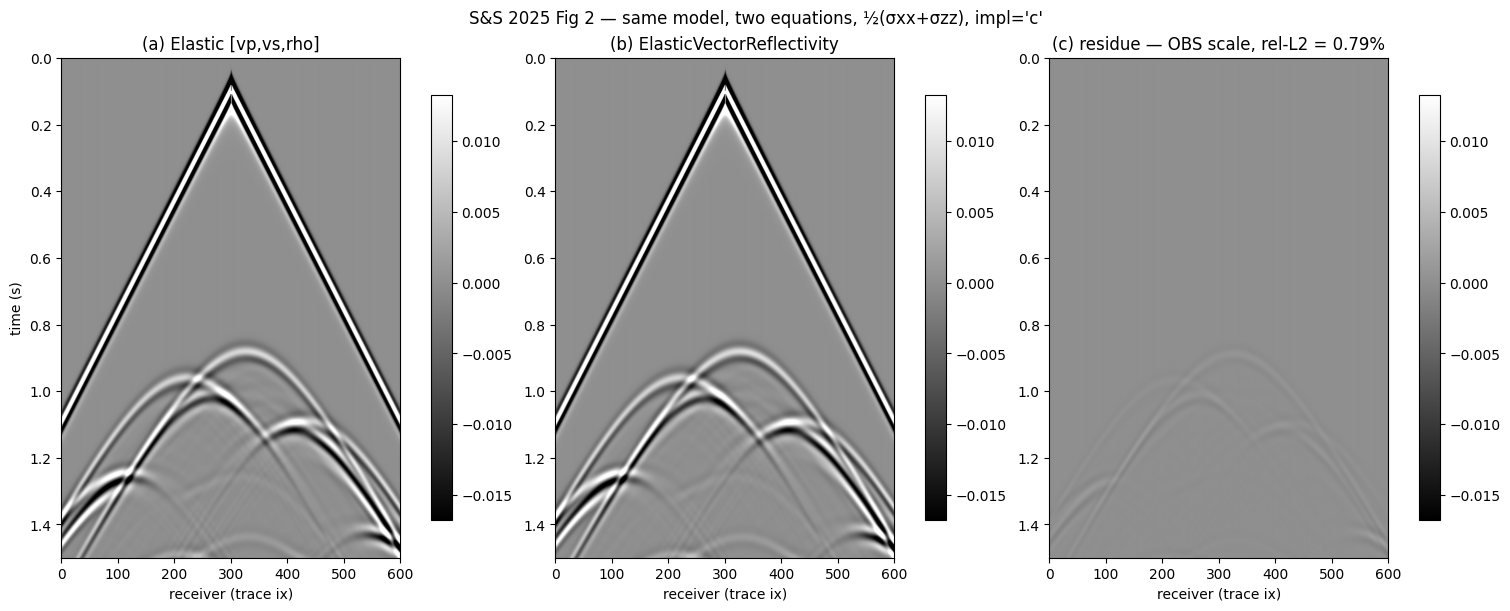

In [4]:
resid = shot_b - shot_a
def rel_l2(b, a): return float(np.linalg.norm(b - a) / max(np.linalg.norm(a), 1e-30))

rel_global = rel_l2(shot_b, shot_a)
n_early    = int(round(0.3 / DT))                 # first 0.3 s: before the first reflection
rel_early  = rel_l2(shot_b[:n_early], shot_a[:n_early])
fa, fb     = shot_a.ravel(), shot_b.ravel()
cos        = float(fa @ fb / max(np.linalg.norm(fa) * np.linalg.norm(fb), 1e-30))
print(f'global rel-L2      : {100 * rel_global:.3f} %    (paper target ~1%)')
print(f'direct-wave rel-L2 : {rel_early:.2e}     (first {n_early * DT:.2f} s, pre-reflection)')
print(f'cosine similarity  : {cos:.6f}')

vmin, vmax = np.percentile(shot_a, [2, 98])       # OBS (data) scale, shared by all 3 panels
ext = [0, NX, NT * DT, 0]
fig, ax = plt.subplots(1, 3, figsize=(15, 6), constrained_layout=True)
panels = [
    (ax[0], shot_a, '(a) Elastic [vp,vs,rho]'),
    (ax[1], shot_b, '(b) ElasticVectorReflectivity'),
    (ax[2], resid,  f'(c) residue — OBS scale, rel-L2 = {100*rel_global:.2f}%'),
]
for a, d, ttl in panels:
    im = a.imshow(d, aspect='auto', cmap='gray', vmin=vmin, vmax=vmax, extent=ext)
    a.set_title(ttl); a.set_xlabel('receiver (trace ix)'); fig.colorbar(im, ax=a, shrink=0.85)
ax[0].set_ylabel('time (s)')
fig.suptitle("S&S 2025 Fig 2 — same model, two equations, ½(σxx+σzz), impl='c'")
plt.show()

## 5. Figure 3 — wavefield snapshot at t = 0.7 s

Full-grid wavefield snapshots are exposed only by the **eager** backend
(`impl='c'` returns only the receiver gather). The eager step is validated to
reproduce `impl='c'`, so this is the same physics — we just do one short eager
run per equation up to the snapshot time. The residue column is plotted on the
**same colour scale as the wavefield**, so it reads essentially blank — the two
solvers' snapshots are indistinguishable at the field amplitude.

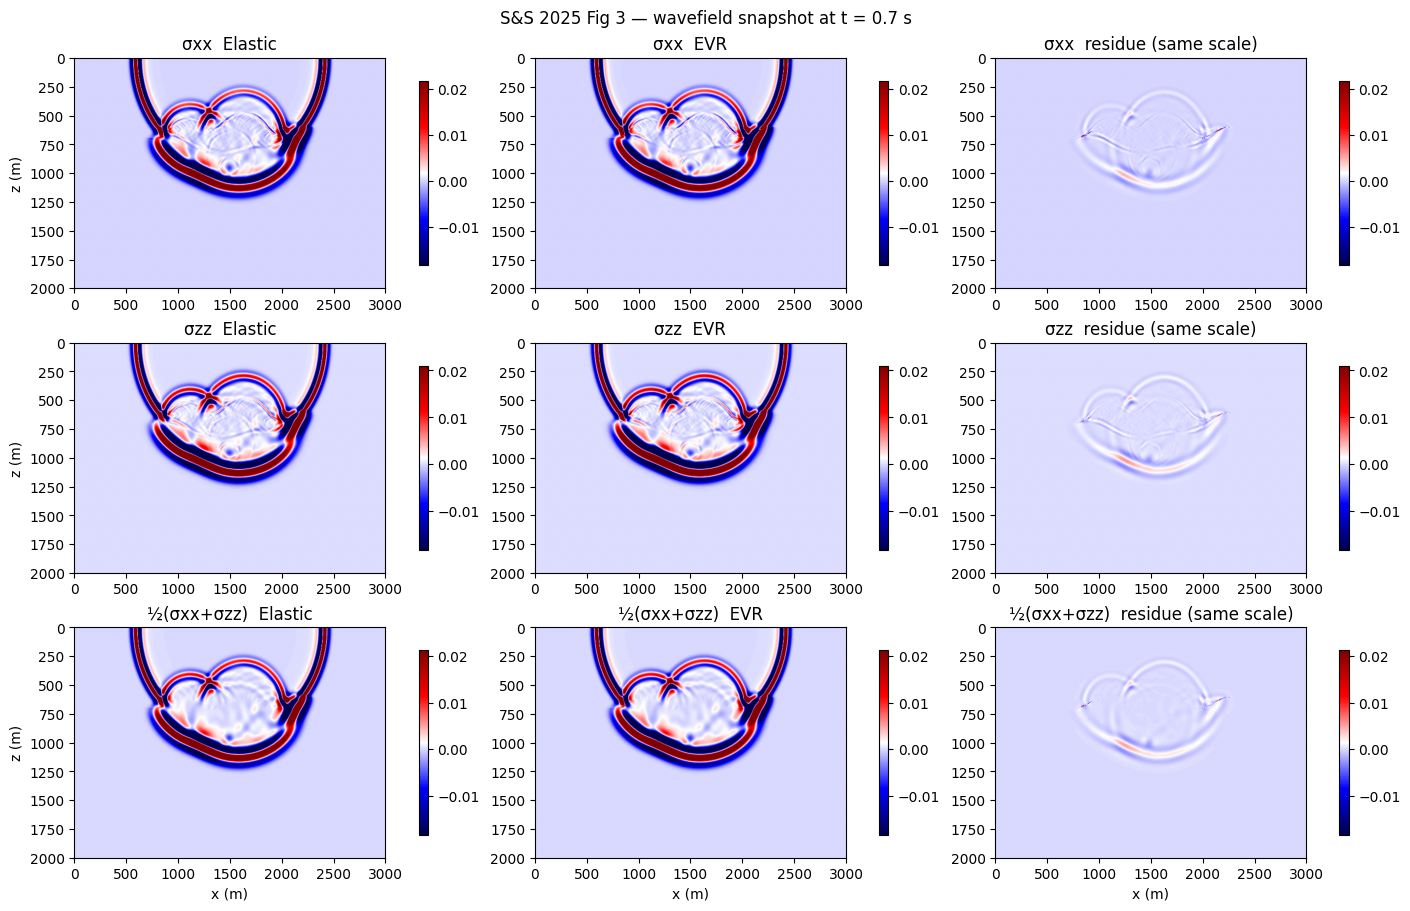

In [5]:
NT_SNAP, IT_SNAP = 1600, 1400          # 1400 * 5e-4 s = 0.7 s
t_snap   = np.arange(NT_SNAP, dtype=np.float32) * DT - DELAY
wav_snap = torch.tensor(ricker(t_snap, f=FREQ).astype(np.float32), device=device)

def snapshot(equation_cls, models):
    eq   = equation_cls(spatial_order=SO, device=device, backend='torch')
    prop = PropTorch(eq, shape=(NZ, NX), abcn=ABCN, dh=DH, dt=DT, nt=NT_SNAP,
                     free_surface=False, use_ckpt=False, impl='eager',
                     eager_options={'use_compile': False},
                     source_type=['sxx', 'szz'], receiver_type=['sxx', 'szz'])
    with torch.no_grad():
        _, snaps = prop(wav_snap, sources, receivers, models=models,
                        return_wavefield=True, snapshot_times=[IT_SNAP])
    # snaps: (n_snap, n_field=15, B=1, 1, nz_pad, nx_pad); field idx 2=sxx, 3=szz
    nz_pad, nx_pad = snaps.shape[-2:]
    pz, px = (nz_pad - NZ) // 2, (nx_pad - NX) // 2
    s = snaps[0, :, 0, 0]
    sxx = s[2, pz:pz + NZ, px:px + NX].cpu().numpy()
    szz = s[3, pz:pz + NZ, px:px + NX].cpu().numpy()
    return sxx, szz

sxx_a, szz_a = snapshot(Elastic, [vp, vs, rho])
sxx_b, szz_b = snapshot(ElasticVectorReflectivity, [vp, vs, Rp_x, Rp_z, Rs_x, Rs_z])
pres_a, pres_b = 0.5 * (sxx_a + szz_a), 0.5 * (sxx_b + szz_b)

ext = [0, NX * DH, NZ * DH, 0]
rows = [('σxx', sxx_a, sxx_b), ('σzz', szz_a, szz_b), ('½(σxx+σzz)', pres_a, pres_b)]
fig, ax = plt.subplots(3, 3, figsize=(14, 9), constrained_layout=True)
for r, (nm, A, B) in enumerate(rows):
    lo, hi = np.percentile(A, [2, 98])            # field scale from the Elastic reference
    rr = B - A
    for c, (d, ttl) in enumerate([
        (A,  f'{nm}  Elastic'),
        (B,  f'{nm}  EVR'),
        (rr, f'{nm}  residue (same scale)'),       # plotted on the field scale
    ]):
        im = ax[r, c].imshow(d, cmap='seismic', vmin=lo, vmax=hi, aspect='auto', extent=ext)
        ax[r, c].set_title(ttl); fig.colorbar(im, ax=ax[r, c], shrink=0.8)
    ax[r, 0].set_ylabel('z (m)')
for c in range(3): ax[2, c].set_xlabel('x (m)')
fig.suptitle('S&S 2025 Fig 3 — wavefield snapshot at t = 0.7 s')
plt.show()

## Summary

| metric | result | paper |
|---|---|---|
| global shot-gather rel-L2 | ~1 % | "minor discrepancies at interface boundaries" |
| direct-wave rel-L2 (pre-reflection) | ~1e-7 | "the direct wave is identical" |
| residue location | layer interfaces only | "interpolation errors at the boundary interface" |

The first-order momentum–stress `ElasticVectorReflectivity` solver reproduces the
standard variable-density Virieux `Elastic` solver to ~1 % on the same physical
model, with the residue confined to the impedance contrasts — confirming the
Soares & Sacchi (2025) reparameterisation. The model carries **no density**;
all of it is encoded in the vector reflectivity `R = ½ ∂ ln Z`.

---

<p><strong>Download this notebook</strong> &mdash; <a href="16_elastic_vector_reflectivity.ipynb" download><code>16_elastic_vector_reflectivity.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/16_elastic_vector_reflectivity.ipynb">view on GitHub</a></p>